# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

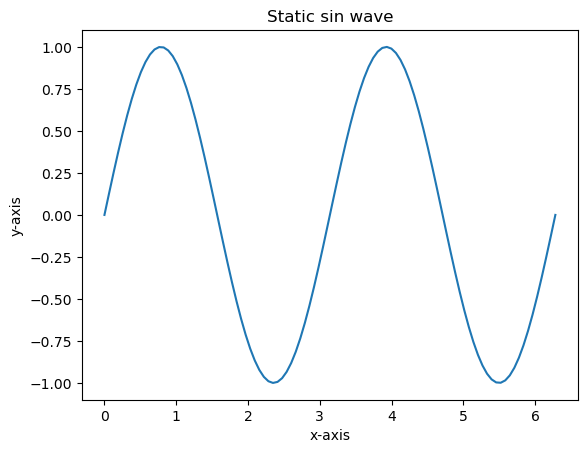

In [34]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

# Create 100 evenly spaced x-values from 0 to 2 pi
x = np.linspace(0, 2 * np.pi, 100)
# Calculate the sin of each given x value
y = np.sin(2 * x)

# Plot the static wave
plt.plot(x, y) # drawing a line
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title("Static sin wave")
plt.show()

In [35]:
# Your comment here
# We change y = np.sin(x) to y = np.sin(2*x) so that the wave moves twice as fast. Doing this will increase the frequency and make it oscillate twice as fast.

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

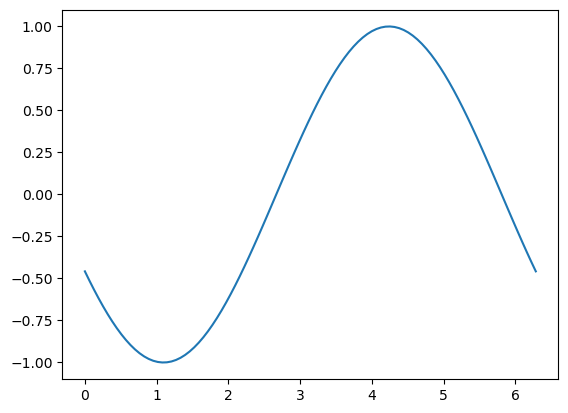

In [36]:
# Your code here
import matplotlib.animation as animation

# Making our drawing space
fig, ax = plt.subplots()

# Creating our "moving" sine wave plot

line, = ax.plot(x, np.sin(x))

def update(frame):
    """
    Updating my sine wave by shifting it horizontally
    framw(integer) = current frame number, increasing with time
    line, (tuple) = the updated line object (Being redrawn)
    """
    line.set_ydata(np.sin(x+frame/10.0))
    
    return line,

ani = animation.FuncAnimation(fig, update, frames = 100, interval = 50, blit = True)
ani.save("animation1.gif", writer="pillow", fps=20)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [37]:
# Your comment here
# For blit=True, only parts of the figure that actually change between frames are redrawn. This makes the animation faster and smoother.
# For blit=False, every part of the figure is redrawn for every frame. This makes the animation slower but is better for more complex animations.

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

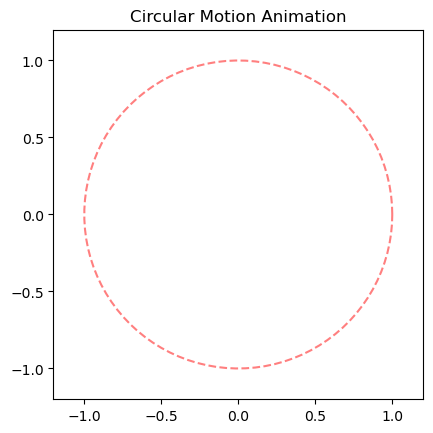

In [38]:
# Your code here

# Figure and Axes
fig, ax = plt.subplots()
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_title("Circular Motion Animation")

# Initialize the dot
dot, = ax.plot([], [], 'bo', markersize=8)

# Theta values for full circle
theta_vals = np.linspace(0, 2 * np.pi, 100)

# Circle outline
ax.plot(np.cos(theta_vals), np.sin(theta_vals), 'r--', alpha=0.5)

plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [39]:
# Your code here

# Update function
def update(frame):
    theta = 2 * np.pi * frame / 100  # Increment theta
    x = np.cos(theta)  # X position
    y = np.sin(theta)  # Y position
    dot.set_data(x, y)  # Update dot position
    return dot,

# Create animation
ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)

# Save as GIF
ani.save("circular_motion.gif", writer=animation.PillowWriter(fps=20))

print("GIF saved as 'circular_motion.gif'.")

C:\Users\khons\AppData\Local\Temp\ipykernel_9476\2404463477.py:8: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot.set_data(x, y)  # Update dot position
C:\Users\khons\AppData\Local\Temp\ipykernel_9476\2404463477.py:8: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot.set_data(x, y)  # Update dot position


GIF saved as 'circular_motion.gif'.


## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [40]:
# Your code here

# Gravitational constant
G = 6.67430e-11

# Mass of celestial bodies (kg)
M_sun = 1.9885e30  # Mass of the Sun
M_earth = 5.972e24  # Mass of the Earth
M_mars = 6.39e23  # Mass of Mars
M_comet = 6.39e20  # Assumed mass of the comet

# Astronomical unit (AU) in meters
AU = 1.496e11  # Distance from Earth to Sun

# Time conversion
daysec = 86400  # Number of seconds in a day

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [41]:
# Your code here

e_ap_v = 29290  # Earth velocity at aphelion (m/s)
m_ap_v = 22000  # Mars velocity at aphelion (m/s)
comet_v = 7000  # Comet velocity (m/s)

Run the cell below to define some gravitational constants because we expect no mass loss:

In [42]:
# Your code here
# Not sure what's suppose to be here. Also my example file is not opening.

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [43]:
# Your code here
# Initial positions at aphelion (m)
xe, ye, ze = 1.0167 * AU, 0, 0        # Earth
xm, ym, zm = 1.666 * AU, 0, 0         # Mars
xc, yc, zc = 2.0 * AU, 0.3 * AU, 0    # Comet

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [44]:
# Your code here
# Initial velocities at aphelion (m/s)
xve, yve, zve = 0, e_ap_v, 0        # Earth
xvm, yvm, zvm = 0, m_ap_v, 0        # Mars
xvc, yvc, zvc = 0, comet_v, 0       # Comet

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [45]:
# Your code here
# Sun initial position
xs, ys, zs = 0, 0, 0  

# Sun initial velocity
xvs, yvs, zvs = 0, 0, 0  

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [46]:
# Your code here

t = 0  # Initial time (s)
dt = 1 * daysec  # Time step (1 day in s)
years = 5
sim_years = years * 365 * daysec  # Total time

Create empty lists to store all of your varibles. Run the cell below.

In [47]:
# Store the orbits:

time_list = []

# Position lists
x_sun, y_sun, z_sun = [], [], []
x_earth, y_earth, z_earth = [], [], []
x_mars, y_mars, z_mars = [], [], []
x_comet, y_comet, z_comet = [], [], []

# Velocity lists
vx_sun, vy_sun, vz_sun = [], [], []
vx_earth, vy_earth, vz_earth = [], [], []
vx_mars, vy_mars, vz_mars = [], [], []
vx_comet, vy_comet, vz_comet = [], [], []

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [57]:
# Your code here
################ Earth #############
rx_e, ry_e, rz_e = xe - xs, ye - ys, ze - zs
modr3_e = (rx_e**2 + ry_e**2 + rz_e**2)**1.5
fx_e = -G * M_sun * rx_e / modr3_e
fy_e = -G * M_sun * ry_e / modr3_e

xve += fx_e * dt / M_earth
yve += fy_e * dt / M_earth
xe += xve * dt
ye += yve * dt

x_earth.append(xe)
y_earth.append(ye)

################ Mars ##############
rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
fx_m = -G * M_sun * rx_m / modr3_m
fy_m = -G * M_sun * ry_m / modr3_m

xvm += fx_m * dt / M_mars
yvm += fy_m * dt / M_mars
xm += xvm * dt
ym += yvm * dt

x_mars.append(xm)
y_mars.append(ym)

################ Comet ##############
rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
fx_c = -G * M_sun * rx_c / modr3_c
fy_c = -G * M_sun * ry_c / modr3_c

xvc += fx_c * dt / M_comet
yvc += fy_c * dt / M_comet
xc += xvc * dt
yc += yvc * dt

x_comet.append(xc)
y_comet.append(yc)

################ Sun ##############
xvs += -(fx_e + fx_m + fx_c) * dt / M_sun
yvs += -(fy_e + fy_m + fy_c) * dt / M_sun
xs += xvs * dt
ys += yvs * dt

x_sun.append(xs)
y_sun.append(ys)

t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

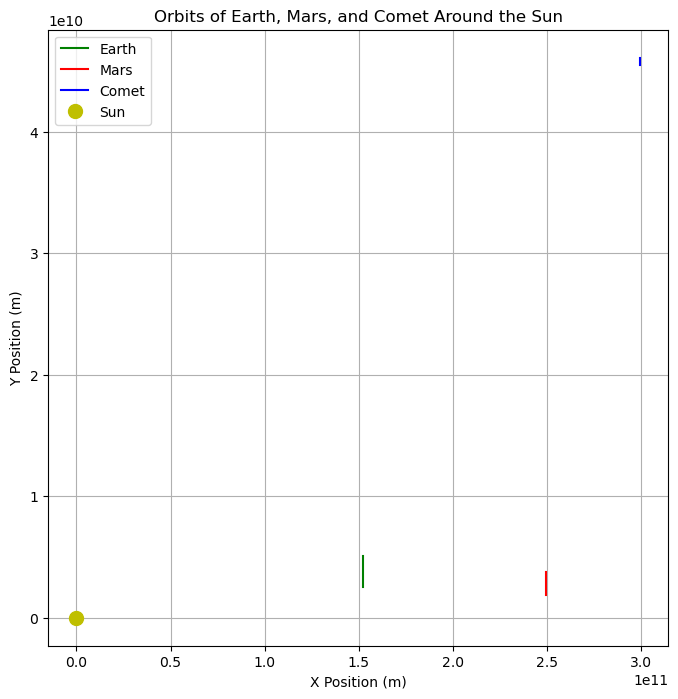

In [58]:
# Your code here 

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot orbits
ax.plot(x_earth, y_earth, '-g', label='Earth')  # Green for Earth
ax.plot(x_mars, y_mars, '-r', label='Mars')  # Red for Mars
ax.plot(x_comet, y_comet, '-b', label='Comet')  # Blue for Comet

# Plot the Sun as a stationary point
ax.plot(0, 0, 'yo', markersize=10, label='Sun')  # Yellow for Sun

# Labels and title
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Orbits of Earth, Mars, and Comet Around the Sun")

# Legend and grid
ax.legend()
ax.grid()

# Show the plot
plt.show()


Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

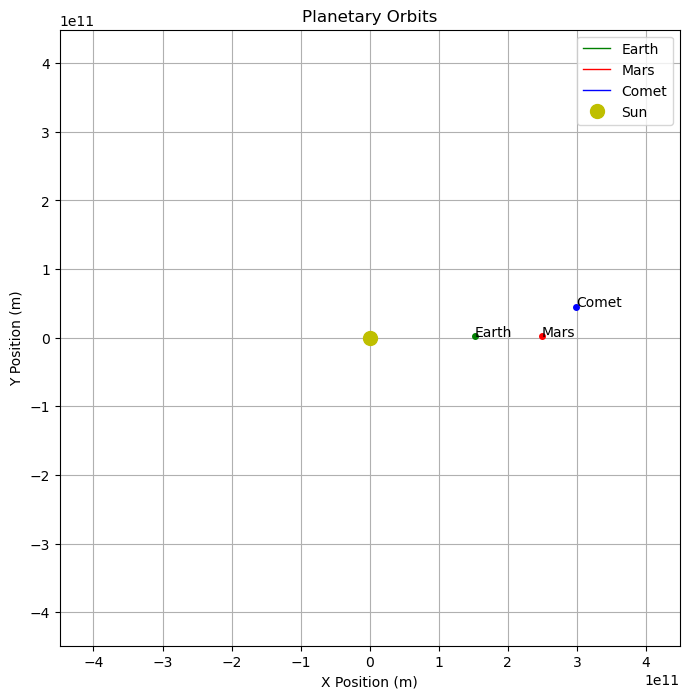

In [59]:
# Your code here

import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

# Unpack the lines
line_e, = ax.plot([], [], '-g', lw=1, label="Earth")
line_m, = ax.plot([], [], '-r', lw=1, label="Mars")
line_c, = ax.plot([], [], '-b', lw=1, label="Comet")

# Unpack the points
point_e, = ax.plot([], [], 'go', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'bo', markersize=4)
point_sun, = ax.plot(0, 0, 'yo', markersize=10, label="Sun")

# Add text labels
text_e = ax.text(AU, 0, 'Earth')
text_m = ax.text(1.5 * AU, 0, 'Mars')
text_c = ax.text(2 * AU, 0, 'Comet')

ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Planetary Orbits")
ax.grid()

def update_orbits(i):
    line_e.set_data(x_earth[:i], y_earth[:i])
    point_e.set_data([x_earth[i]], [y_earth[i]])
    text_e.set_position((x_earth[i], y_earth[i]))

    line_m.set_data(x_mars[:i], y_mars[:i])
    point_m.set_data([x_mars[i]], [y_mars[i]])
    text_m.set_position((x_mars[i], y_mars[i]))

    line_c.set_data(x_comet[:i], y_comet[:i])
    point_c.set_data([x_comet[i]], [y_comet[i]])
    text_c.set_position((x_comet[i], y_comet[i]))

    return line_e, point_e, text_e, line_m, point_m, text_m, line_c, point_c, text_c

ani = animation.FuncAnimation(fig, update_orbits, frames=len(x_earth), interval=1, blit=True)

plt.show()

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

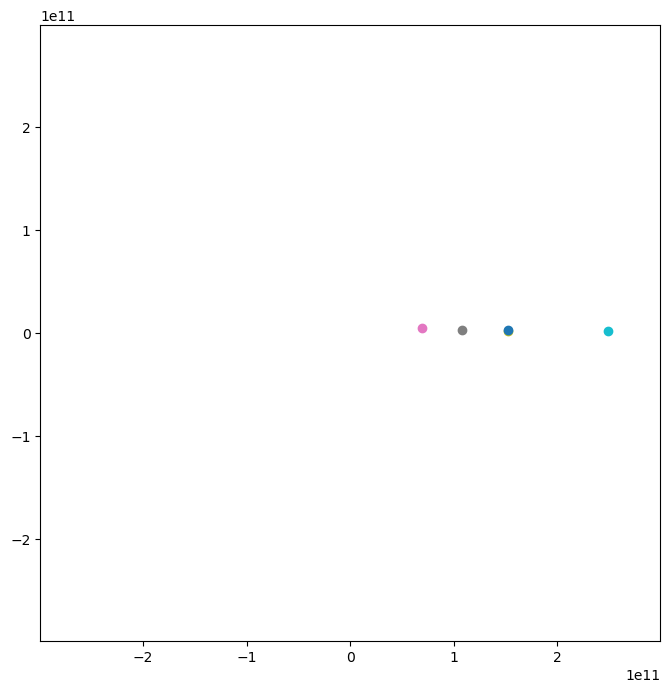

In [74]:
# Your code here

# Constants
G, AU, daysec = 6.67430e-11, 1.496e11, 86400
Ms, Me, Mm, Mv, Mmer, Mmoon = 1.989e30, 5.972e24, 6.417e23, 4.867e24, 3.285e23, 7.347e22

# Initial positions (m) and velocities (m/s)
bodies = {
    "Mercury": [0.467 * AU, 0, 0, 58980],
    "Venus": [0.723 * AU, 0, 0, 34790],
    "Earth": [1.0167 * AU, 0, 0, 29290],
    "Mars": [1.666 * AU, 0, 0, 21970],
    "Moon": [1.0167 * AU + 384400000, 0, 0, 29290 + 1022],
    "Sun": [0, 0, 0, 0]
}

masses = {"Mercury": Mmer, "Venus": Mv, "Earth": Me, "Mars": Mm, "Moon": Mmoon, "Sun": Ms}

# Simulation parameters
t, dt, years = 0, 1 * daysec, 5
sim_years = years * 365 * daysec

# Store positions
orbits = {name: [[], []] for name in bodies}

while t < sim_years:
    for name, (x, y, vx, vy) in bodies.items():
        if name != "Sun":
            rx, ry = x - bodies["Sun"][0], y - bodies["Sun"][1]
            r3 = (rx**2 + ry**2)**1.5
            ax, ay = -G * Ms * rx / r3, -G * Ms * ry / r3
            vx, vy = vx + ax * dt, vy + ay * dt
            x, y = x + vx * dt, y + vy * dt
            bodies[name] = [x, y, vx, vy]
            orbits[name][0].append(x)
            orbits[name][1].append(y)
    t += dt

# Find the maximum number of frames (based on the longest orbit data)
max_length = max(len(orbit[0]) for orbit in orbits.values())  

# Set up the figure for plotting
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-2 * AU, 2 * AU), ax.set_ylim(-2 * AU, 2 * AU)

# Set up the line and point plots
lines = {name: ax.plot([], [], '-')[0] for name in orbits}
points = {name: ax.plot([], [], 'o')[0] for name in orbits}

def update(i):
    # Ensure we only update the data if the index is within bounds
    for name in orbits:
        if i < len(orbits[name][0]):  # Ensure the index is within bounds
            lines[name].set_data(orbits[name][0][:i], orbits[name][1][:i])  # Update line data
            # To avoid the deprecation warning, pass a sequence even for a single point
            points[name].set_data([orbits[name][0][i]], [orbits[name][1][i]])  # Update point data with sequence
    return [line for line in lines.values()] + [point for point in points.values()]

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=max_length, interval=10, blit=True)

# Display
plt.show()

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [76]:
# Your code here
ani.save('solar_system_orbits.gif', writer='pillow', fps=30)

Upload this notebook and your animations to Gradescope!